# Rule-level diagnostic companion to staging_sensitivity.ipynb

Pick an index from the source notebook's selected rules. For one stage, compare a rule-bearing eligible FOV with an eligible no-rule FOV, then inspect valid patches, antecedent hits, consequent hits, joint hits, and misses. Reconstructed binary metrics are diagnostic; stored mining FDR remains authoritative.


In [1]:
from pathlib import Path
import sys

ROOT = next(folder for folder in (Path.cwd().resolve(), *Path.cwd().resolve().parents)
            if (folder / 'result_summary' / 'data_helper.py').exists())
sys.path[:0] = [str(ROOT / 'result_summary'),
                str(ROOT / 'result_summary' / 'differential_rules'),
                str(ROOT / 'result_summary' / 'complex_rules')]
import complex_investigation as ci
import rule_diagnostics as rd
from IPython.display import display

In [2]:
SOURCE = ROOT / 'result_summary' / 'complex_rules' / 'staging_sensitivity.ipynb'
CONFIG = ci.Config(max_items=4, support=.01,
                   expected_support=.01, confidence=.5, min_cells=20)
INFORMATIVE, MODE = True, 'all'
SPECS = rd.selected_from_notebook(SOURCE)
display(SPECS.rename_axis('index'))

,organ,rule,kind
index,,,
0,Colon,Goblet -> CD8T + Fibroblast + Plasma,avoids
1,Duodenum,Muscle -> Endothelial + Plasma_CD38,avoids
2,Colon,Epithelial + Fibroblast -> Plasma,attracts
3,Duodenum,Fibroblast + Paneth -> Epithelial + Neuron,attracts


In [3]:
cells, metadata, rules = ci.load(CONFIG)

Dropped 21 FOVs: Control_S


Loaded 598093 cells; FOVs: 267, biopsies: 73, patients: 71


Read results_CN_pairwise.csv + results_CN_complex.csv


{'max_items': 4, 'min_cells': 20, 'mining_fdr': 0.05, 'support': 0.01, 'confidence': 0.5, 'expected_support': 0.01, 'score': 'Clinical score', 'min_fovs': 5, 'min_patients': 3, 'min_group_fovs': 10, 'visible_gap': 0.15, 'attraction_lift_gap': 0.3, 'avoidance_lift_gap': 0.15, 'permutations': 4999, 'top_n': 8}
690,345 stored center-specific occurrences; distinct cell types only
Mining settings: {'settings': {'weighting': 'binary', 'method': 'CN', 'radius': 25.0, 'min_support': 0.01, 'min_lift': 1.2, 'max_items_per_rule': 4, 'bandwidth': 15.0, 'k_neighbors': None, 'min_cells_per_patch': 2, 'max_one_type_share': 0.9, 'min_patches': 15, 'strong_confidence': 0.9, 'min_support_when_strong': 0.005, 'min_confidence': 0.5, 'min_leverage': 0.0005, 'min_conviction': 1.3, 'include_avoidance_rules': True, 'avoidance_max_lift': 0.8, 'avoidance_max_leverage': None, 'avoidance_min_expected_meetings': 30, 'min_label_count': 5, 'min_label_share': None, 'decay_distance': 15.0}, 'steps': {'n_shuffles': 100

In [4]:
def show_selected(index, stage=None, state=None):
    if not 0 <= index < len(SPECS):
        print(f'No selected rule at index {index}; {len(SPECS)} available.')
        return
    spec = SPECS.iloc[index]
    direction = str(spec.get('direction', spec.get('kind', ''))).lower()
    if state is None:
        state = -1 if 'avoid' in direction else (1 if 'attract' in direction else None)
    rd.compare_fields(spec.rule, spec.organ, cells, metadata, rules, CONFIG,
                      stage=stage, state=state, informative=INFORMATIVE, mode=MODE)

Colon · Severe: 1/20 eligible FOVs show informative avoidance.
Comparison: rule-bearing GVHD_41_FOV_2 versus eligible no-rule GVHD_33_FOV_2.
A missing stored row does not prove spatial independence: candidate pruning and shuffle FDR matter.


,,center,status,stored_kind,stored_lift,stored_fdr,valid,antecedent,consequent,joint,Support,Confidence,Lift,Expected_support
rule FOV,0,Goblet,passes investigation gate,avoids,0.172324,0.003873,2036,318,483,13,0.006385,0.040881,0.172324,0.037053
no-rule FOV,0,Goblet,filtered: shorter rule explains it,avoids,0.261511,0.015856,1471,275,225,11,0.007478,0.040000,0.261511,0.028595


No-rule FOV status for this center: filtered: shorter rule explains it.


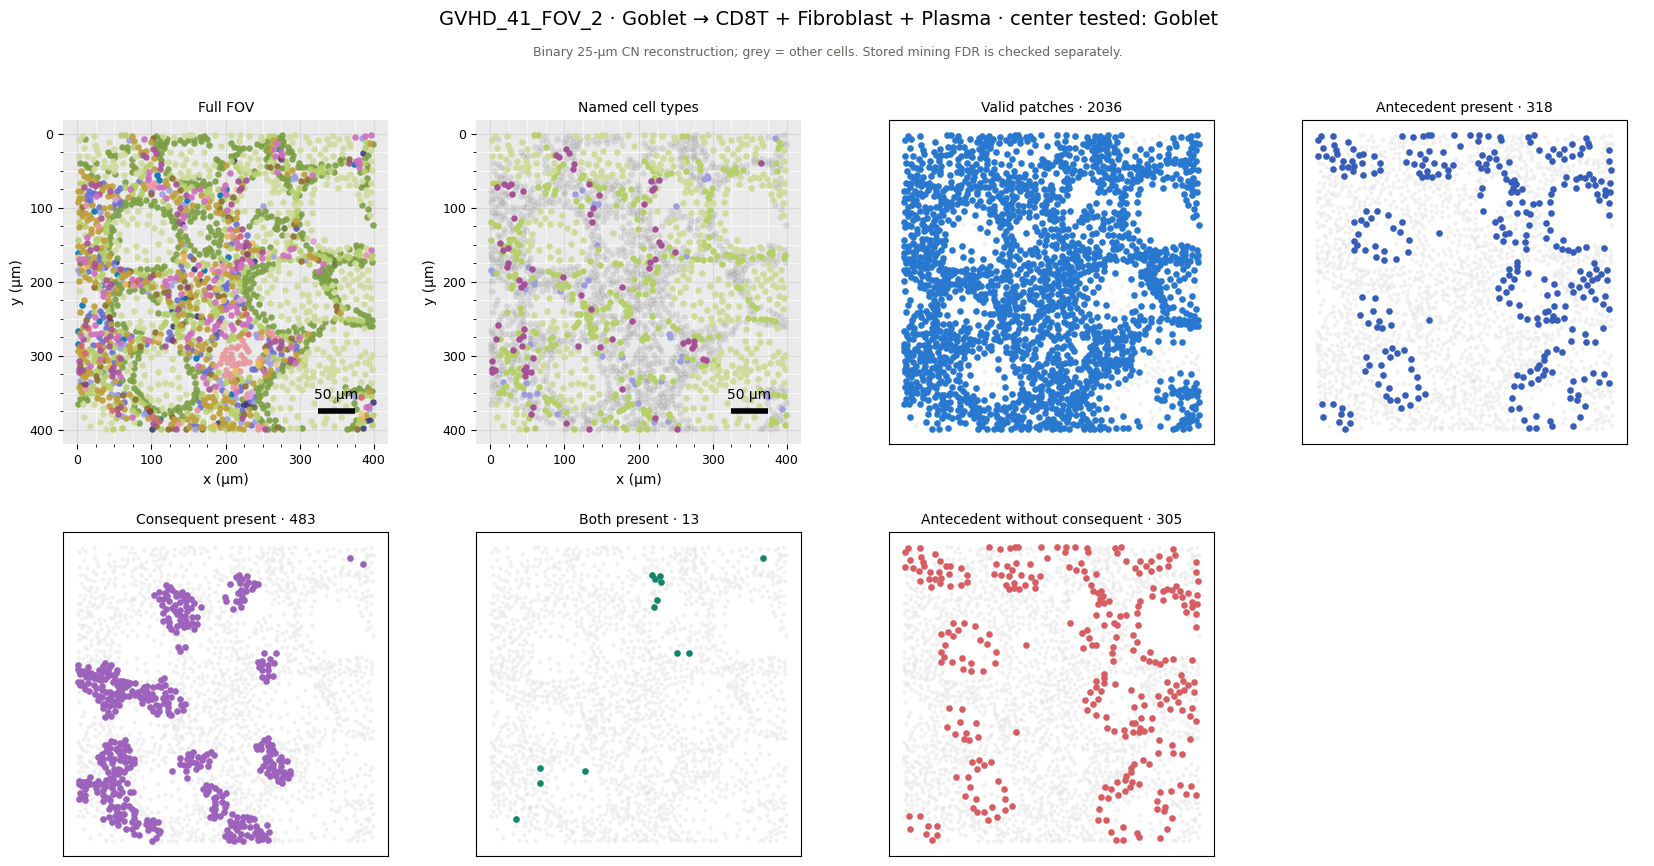

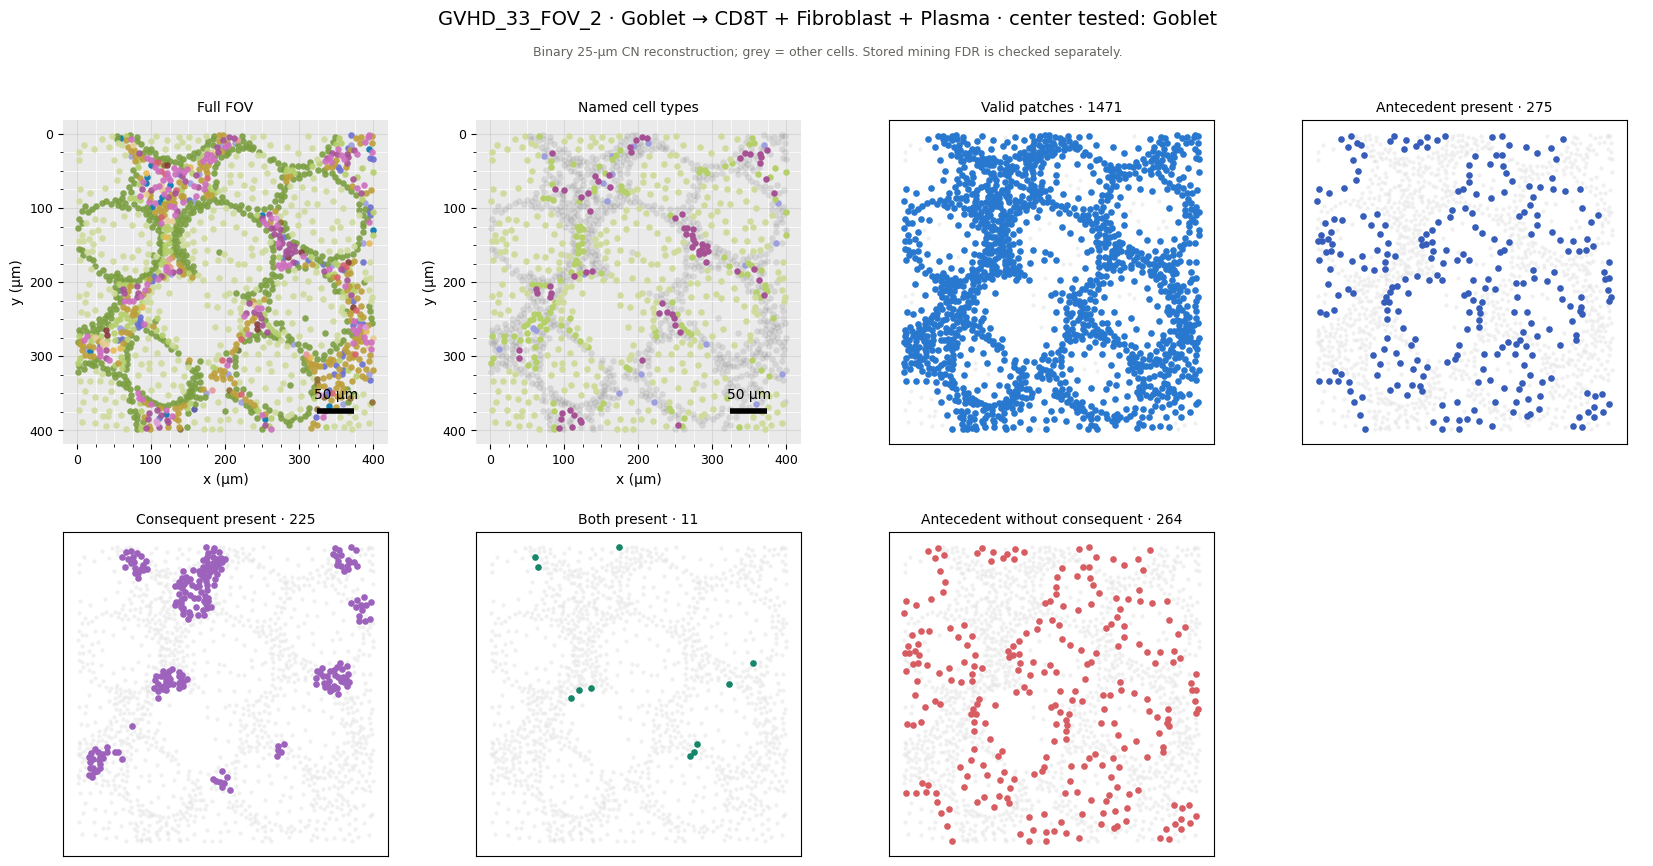

In [5]:
show_selected(0)